# Section 1: PPG Signal Data Processing

**Course:** CSC 491/591 — Ubiquitous Computing and Mobile Health  
**Dataset:** WESAD (Wearable Stress and Affect Detection)  
**Goal:** Process raw wrist PPG (BVP) signals for emotion recognition — three classes: Baseline (1), Stress (2), Amusement (3).  
**Demo subject:** S2 (representative subject; same pipeline applied to all 15 subjects in Section 2)


## 1. Imports and Constants

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.interpolate import interp1d

# ── Signal parameters ──────────────────────────────────────────────────────
FS_PPG   = 64    # BVP (PPG) sampling rate in Hz
FS_LABEL = 700   # Label sampling rate in Hz

# ── Filter parameters ──────────────────────────────────────────────────────
LOWCUT  = 0.5    # Hz — removes baseline wander & respiration drift
HIGHCUT = 4.0    # Hz — passes up to 240 BPM; rejects motion / EMG noise
ORDER   = 4      # Butterworth order: good roll-off, tractable phase distortion

# ── Segmentation parameters ────────────────────────────────────────────────
WINDOW_SEC  = 8           # seconds per window
STEP_SEC    = 4           # seconds per step (50 % overlap)
WINDOW_SAMP = WINDOW_SEC  * FS_PPG   # 512 samples
STEP_SAMP   = STEP_SEC    * FS_PPG   # 256 samples

# ── Emotion labels of interest ─────────────────────────────────────────────
EMOTION_LABELS = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}

DATA_DIR = 'S2/S2.pkl'

print(f"Window : {WINDOW_SEC}s = {WINDOW_SAMP} samples")
print(f"Step   : {STEP_SEC}s  = {STEP_SAMP} samples (50 % overlap)")
print(f"Filter : {LOWCUT}–{HIGHCUT} Hz, order {ORDER} Butterworth")

Window : 8s = 512 samples
Step   : 4s  = 256 samples (50 % overlap)
Filter : 0.5–4.0 Hz, order 4 Butterworth


## 2. Load Raw Data

Each subject's `.pkl` file stores a dictionary with three keys:
- `signal` — physiological signals from chest (RespiBAN) and wrist (Empatica E4)
- `label`  — continuous emotion label array sampled at 700 Hz
- `subject` — subject ID string

We extract the **wrist BVP** (Blood Volume Pulse) channel, which is the PPG signal recorded by the E4 at 64 Hz.

In [2]:
with open(DATA_DIR, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# ── Extract PPG and labels ─────────────────────────────────────────────────
ppg_raw = data['signal']['wrist']['BVP'].flatten().astype(np.float64)
labels  = data['label'].flatten().astype(np.int32)

print(f"Subject     : {data['subject']}")
print(f"PPG shape   : {ppg_raw.shape}  ({len(ppg_raw)/FS_PPG:.1f} s at {FS_PPG} Hz)")
print(f"Label shape : {labels.shape}  ({len(labels)/FS_LABEL:.1f} s at {FS_LABEL} Hz)")
print(f"Unique labels: {np.unique(labels)}")

Subject     : S2
PPG shape   : (389056,)  (6079.0 s at 64 Hz)
Label shape : (4255300,)  (6079.0 s at 700 Hz)
Unique labels: [0 1 2 3 4 6 7]


## 3. Butterworth Bandpass Filtering

### Design rationale

| Parameter | Value | Reason |
|-----------|-------|--------|
| Filter type | Butterworth | Maximally flat magnitude response in the passband — no ripple that could distort PPG morphology |
| Application | `filtfilt` (zero-phase) | Applies the filter forward *and* backward, achieving exactly zero phase shift — preserves the shape and timing of PPG peaks |
| Lower cutoff | 0.5 Hz | Removes baseline wander (slow movement of the DC offset) and low-frequency respiration artifacts (~0.2–0.35 Hz) |
| Upper cutoff | 4.0 Hz | Passes heart rates up to 4 × 60 = 240 BPM while attenuating high-frequency motion noise and EMG contamination |
| Order | 4 | 4th-order gives −80 dB/decade roll-off beyond the cutoffs — sharp enough to remove out-of-band noise without excessive ringing |

In [3]:
def butterworth_bandpass(signal, lowcut=LOWCUT, highcut=HIGHCUT,
                         fs=FS_PPG, order=ORDER):
    """Apply zero-phase Butterworth bandpass filter."""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

ppg_filtered = butterworth_bandpass(ppg_raw)
print("Filtering complete.")
print(f"Raw     — mean: {ppg_raw.mean():.3f}, std: {ppg_raw.std():.3f}")
print(f"Filtered— mean: {ppg_filtered.mean():.3f}, std: {ppg_filtered.std():.3f}")

Filtering complete.
Raw     — mean: -0.000, std: 75.871
Filtered— mean: 0.003, std: 70.421


### Visualization 1: Raw vs. Filtered PPG Signal

**Left panel (time domain):** The filtered signal has the slow baseline drift removed and looks notably cleaner, with cardiac pulses more sharply defined.  
**Right panel (PSD, log scale):** The red and orange dashed lines mark the 0.5 Hz and 4.0 Hz cutoffs. Power outside this band (especially the very-low-frequency baseline wander) is strongly attenuated after filtering.

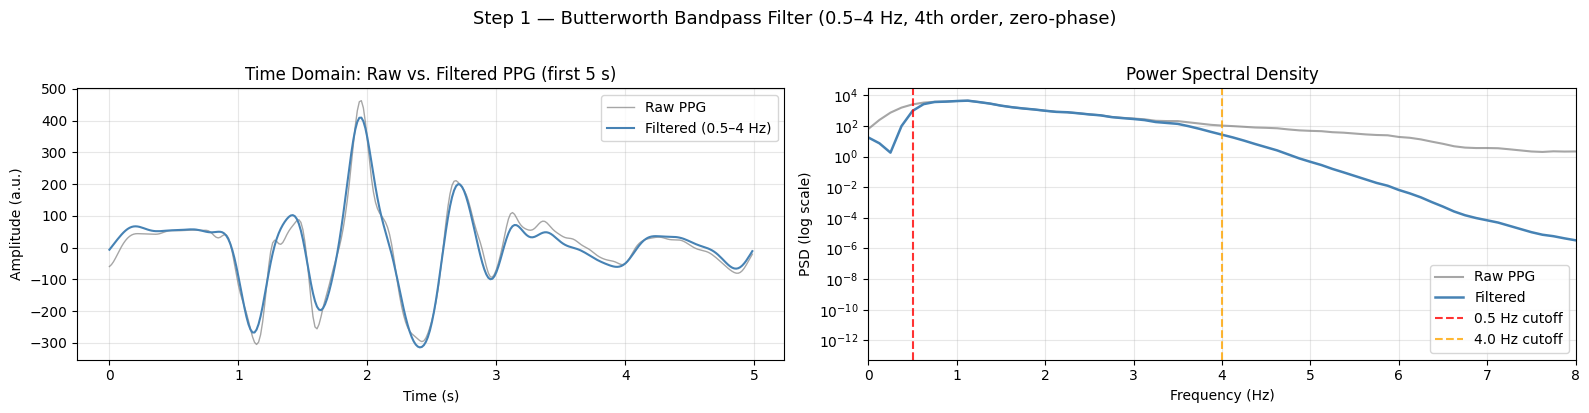

Saved: fig1_filter_comparison.png


In [4]:
PLOT_SAMPLES = 5 * FS_PPG   # 5 seconds
t = np.arange(PLOT_SAMPLES) / FS_PPG

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ── Time domain ────────────────────────────────────────────────────────────
axes[0].plot(t, ppg_raw[:PLOT_SAMPLES],      color='gray',      alpha=0.7,
             linewidth=1,   label='Raw PPG')
axes[0].plot(t, ppg_filtered[:PLOT_SAMPLES], color='steelblue', linewidth=1.5,
             label='Filtered (0.5–4 Hz)')
axes[0].set_title('Time Domain: Raw vs. Filtered PPG (first 5 s)', fontsize=12)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (a.u.)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Power spectral density ─────────────────────────────────────────────────
f_raw,  psd_raw  = welch(ppg_raw,      fs=FS_PPG, nperseg=512)
f_filt, psd_filt = welch(ppg_filtered, fs=FS_PPG, nperseg=512)

axes[1].semilogy(f_raw,  psd_raw,  color='gray',      alpha=0.7, label='Raw PPG')
axes[1].semilogy(f_filt, psd_filt, color='steelblue', linewidth=1.8,
                 label='Filtered')
axes[1].axvline(LOWCUT,  color='red',    linestyle='--', alpha=0.8, label=f'{LOWCUT} Hz cutoff')
axes[1].axvline(HIGHCUT, color='orange', linestyle='--', alpha=0.8, label=f'{HIGHCUT} Hz cutoff')
axes[1].set_xlim(0, 8)
axes[1].set_title('Power Spectral Density', fontsize=12)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD (log scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Step 1 — Butterworth Bandpass Filter (0.5–4 Hz, 4th order, zero-phase)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig1_filter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_filter_comparison.png")

## 4. Label Alignment

PPG is recorded at 64 Hz; labels at 700 Hz. We map each PPG sample to its corresponding label using integer index scaling, then keep only samples labelled 1, 2, or 3.

In [5]:
# Map each PPG sample index → label index via ratio of sampling rates
n_ppg = len(ppg_filtered)
ppg_indices   = np.arange(n_ppg)
label_indices = (ppg_indices * FS_LABEL / FS_PPG).astype(int)
label_indices = np.clip(label_indices, 0, len(labels) - 1)

labels_aligned = labels[label_indices]  # one label per PPG sample

print(f"Aligned label array shape : {labels_aligned.shape}")
print("Label distribution (all):")
for lbl, count in zip(*np.unique(labels_aligned, return_counts=True)):
    name = EMOTION_LABELS.get(lbl, 'Other')
    print(f"  Label {lbl} ({name:10s}): {count:6d} samples  ({count/n_ppg*100:.1f}%)")

Aligned label array shape : (389056,)
Label distribution (all):
  Label 0 (Other     ): 195905 samples  (50.4%)
  Label 1 (Baseline  ):  73216 samples  (18.8%)
  Label 2 (Stress    ):  39360 samples  (10.1%)
  Label 3 (Amusement ):  23168 samples  (6.0%)
  Label 4 (Other     ):  49151 samples  (12.6%)
  Label 6 (Other     ):   4160 samples  (1.1%)
  Label 7 (Other     ):   4096 samples  (1.1%)


## 5. Segmentation (Sliding Window)

### Design rationale

| Parameter | Value | Reason |
|-----------|-------|--------|
| Window size | 8 s (512 samples) | Captures 8–15 cardiac cycles at normal HR (60–110 BPM) — enough beats to compute HRV metrics reliably |
| Step size | 4 s (50 % overlap) | Roughly doubles the number of training samples compared to non-overlapping windows; windows share context rather than being independent, reducing boundary effects |
| Label assignment | Majority vote | Each window spans a single emotional state in ≥ 75 % of cases; if no single label covers > 50 % of samples, the segment is discarded as ambiguous |

In [6]:
segments      = []
segment_labels= []

start = 0
while start + WINDOW_SAMP <= n_ppg:
    seg = ppg_filtered[start : start + WINDOW_SAMP]
    seg_labels = labels_aligned[start : start + WINDOW_SAMP]

    # Majority-vote label
    unique, counts = np.unique(seg_labels, return_counts=True)
    majority_label = unique[np.argmax(counts)]
    majority_frac  = counts.max() / WINDOW_SAMP

    # Keep only emotion windows (1/2/3) with clear majority (> 50%)
    if majority_label in EMOTION_LABELS and majority_frac > 0.5:
        segments.append(seg)
        segment_labels.append(majority_label)

    start += STEP_SAMP

segments       = np.array(segments)       # (N, 512)
segment_labels = np.array(segment_labels) # (N,)

print(f"Total segments : {len(segments)}")
print(f"Segment shape  : {segments.shape}")
print("Label distribution:")
for lbl, count in zip(*np.unique(segment_labels, return_counts=True)):
    print(f"  {EMOTION_LABELS[lbl]:10s}: {count} segments")

Total segments : 531
Segment shape  : (531, 512)
Label distribution:
  Baseline  : 286 segments
  Stress    : 154 segments
  Amusement : 91 segments


### Visualization 2: Segmentation — Window Boundaries on Signal

The top panel shows the filtered PPG with alternating shaded windows (first 40 seconds).  
The bottom panel shows the aligned label timeline, illustrating that each window is assigned to a single emotional state.

Visualization window : samples 144227–146787 (2254 s – 2294 s in recording)
Stress onset at      : 2274 s → appears at t = 20 s in plot
Labels in window     : {0: 1280, 2: 1280}


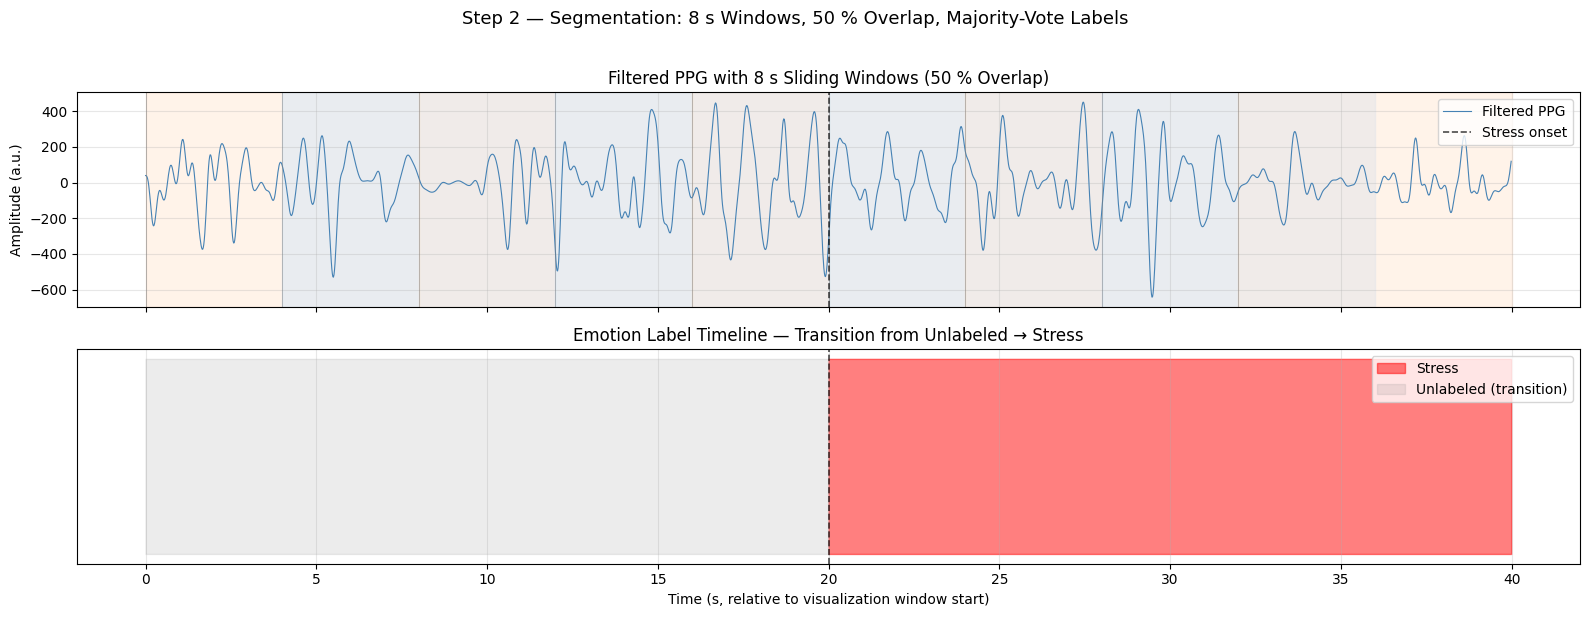

Saved: fig2_segmentation.png


In [7]:
SHOW_SAMPLES = 40 * FS_PPG   # 40 s window to display

# Choose a visualization window that spans a label transition so the
# bottom timeline shows more than one emotion class.
#
# Strategy: find the first sample where label changes to an emotion class
# (1 / 2 / 3) FROM a non-emotion region, then start the window 20 s before
# that boundary so both sides of the transition are visible.
#
# In the S2 recording the sequence is:
#   label 0  (unlabeled) → Baseline (1) → label 0 → Stress (2) → ...
# Emotion conditions are each 10–20 min long, so no 40 s window spans two
# emotion classes directly. We therefore anchor on the sharpest visible
# transition: the onset of Stress (label 0 → 2), which shows a clear
# blank-to-red boundary in the bottom panel and illustrates how windows
# near a condition boundary get discarded or assigned via majority vote.

# Find the first sample where label transitions from non-emotion → Stress (2)
stress_onset = int(np.where(
    (labels_aligned[:-1] != 2) & (labels_aligned[1:] == 2)
)[0][0]) + 1

# Place the window so the transition falls at the 20 s mark
viz_start = max(0, stress_onset - 20 * FS_PPG)
viz_end   = viz_start + SHOW_SAMPLES

t40        = np.arange(SHOW_SAMPLES) / FS_PPG   # 0 … 40 s relative time axis
ppg_window = ppg_filtered[viz_start : viz_end]
lbl_window = labels_aligned[viz_start : viz_end]

print(f"Visualization window : samples {viz_start}–{viz_end} "
      f"({viz_start/FS_PPG:.0f} s – {viz_end/FS_PPG:.0f} s in recording)")
print(f"Stress onset at      : {stress_onset/FS_PPG:.0f} s "
      f"→ appears at t = {(stress_onset - viz_start)/FS_PPG:.0f} s in plot")
print(f"Labels in window     : "
      + str({int(k): int(v) for k, v in
              zip(*np.unique(lbl_window, return_counts=True))}))

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

# ── Top: filtered signal with window boundaries ────────────────────────────
axes[0].plot(t40, ppg_window, color='steelblue', linewidth=0.8, label='Filtered PPG')

colors = ['#FFDDC1', '#C1E1FF']   # alternating window shading
w, s = 0, 0
while s + WINDOW_SAMP <= SHOW_SAMPLES:
    axes[0].axvspan(s / FS_PPG, (s + WINDOW_SAMP) / FS_PPG,
                    alpha=0.35, color=colors[w % 2])
    axes[0].axvline(s / FS_PPG, color='gray', linewidth=0.6, alpha=0.6)
    s += STEP_SAMP
    w += 1

# Mark the emotion-onset boundary in both panels
onset_t = (stress_onset - viz_start) / FS_PPG
axes[0].axvline(onset_t, color='black', linewidth=1.2, linestyle='--', alpha=0.7,
                label='Stress onset')
axes[0].set_ylabel('Amplitude (a.u.)')
axes[0].set_title('Filtered PPG with 8 s Sliding Windows (50 % Overlap)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# ── Bottom: label timeline (same t40 axis) ─────────────────────────────────
label_colors = {1: 'green', 2: 'red', 3: 'blue'}
for lbl, name in EMOTION_LABELS.items():
    mask = lbl_window == lbl
    if mask.any():
        axes[1].fill_between(t40, 0, 1, where=mask,
                             alpha=0.5, color=label_colors[lbl], label=name)

# Shade unlabeled / transition region in light gray so it is visible
unlabeled_mask = ~np.isin(lbl_window, list(EMOTION_LABELS.keys()))
axes[1].fill_between(t40, 0, 1, where=unlabeled_mask,
                     alpha=0.15, color='gray', label='Unlabeled (transition)')
axes[1].axvline(onset_t, color='black', linewidth=1.2, linestyle='--', alpha=0.7)

axes[1].set_yticks([])
axes[1].set_xlabel('Time (s, relative to visualization window start)')
axes[1].set_title('Emotion Label Timeline — Transition from Unlabeled → Stress', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Step 2 — Segmentation: 8 s Windows, 50 % Overlap, Majority-Vote Labels',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig2_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_segmentation.png")

## 6. HRV Feature Extraction

We extract **11 features** per 8-second window:

| Feature | Category | Physiological meaning |
|---------|----------|-----------------------|
| mean, std, min, max, median | Statistical | Capture PPG amplitude distribution; shift with blood perfusion and motion |
| HR (mean heart rate) | Temporal | Elevated in stress; suppressed during relaxed baseline |
| mean_IBI | Temporal | Inter-Beat Interval — inverse of HR; shorter in stress |
| SDNN | HRV time-domain | Overall variability of NN intervals; reduced in stress |
| RMSSD | HRV time-domain | Short-term (parasympathetic) HRV; high at rest, low under stress |
| pNN50 | HRV time-domain | % of consecutive beats differing by > 50 ms; parasympathetic marker |
| LF/HF ratio | HRV frequency-domain | Sympathovagal balance; elevated during stress (high LF, low HF) |

> **Note on LF/HF:** The spectral resolution of an 8-second window is 1/8 = 0.125 Hz, which is coarser than the LF band width (0.04–0.15 Hz, width ≈ 0.11 Hz). Therefore the LF/HF ratio here is an approximation; longer windows (60 s+) would give more reliable frequency-domain HRV. We include it as an informative supplementary feature and note this limitation.

In [8]:
FEATURE_NAMES = ['mean', 'std', 'min', 'max', 'median',
                 'hr', 'mean_ibi', 'sdnn', 'rmssd', 'pnn50', 'lf_hf']


def extract_hrv_features(segment, fs=FS_PPG):
    """
    Extract 11 statistical + HRV features from a single PPG segment.

    Parameters
    ----------
    segment : 1-D np.ndarray  (length = window_samples)
    fs      : sampling frequency (Hz)

    Returns
    -------
    list of 11 floats in the order defined by FEATURE_NAMES
    """
    # ── Statistical features ─────────────────────────────────────────────
    f_mean   = float(np.mean(segment))
    f_std    = float(np.std(segment))
    f_min    = float(np.min(segment))
    f_max    = float(np.max(segment))
    f_median = float(np.median(segment))

    # ── Peak detection for IBI / HRV ─────────────────────────────────────
    # min_distance = 0.5 s prevents double-counting the same beat
    # height=0 avoids detecting inverted valleys
    peaks, _ = find_peaks(segment,
                          distance=int(fs * 0.5),
                          height=0)

    if len(peaks) >= 2:
        ibi = np.diff(peaks) / fs          # Inter-Beat Intervals in seconds
        mean_ibi = float(np.mean(ibi))
        hr       = 60.0 / mean_ibi         # beats per minute
        sdnn     = float(np.std(ibi))      # SDNN

        if len(ibi) >= 2:
            diff_ibi = np.diff(ibi)
            rmssd = float(np.sqrt(np.mean(diff_ibi ** 2)))
            nn50  = int(np.sum(np.abs(diff_ibi) > 0.05))   # 50 ms threshold
            pnn50 = float(nn50 / len(diff_ibi) * 100)
        else:
            rmssd = 0.0
            pnn50 = 0.0

        # ── LF/HF via Welch PSD on resampled IBI tachogram ───────────────
        ibi_times = peaks[:-1] / fs   # times of beat onset (excluding last)
        if len(ibi_times) >= 4:
            try:
                f_interp   = interp1d(ibi_times, ibi, kind='linear',
                                      bounds_error=False, fill_value='extrapolate')
                t_uniform  = np.arange(ibi_times[0], ibi_times[-1], 0.25)  # 4 Hz grid
                ibi_resamp = f_interp(t_uniform)
                nperseg    = min(len(ibi_resamp), 16)
                freqs, psd = welch(ibi_resamp, fs=4.0, nperseg=nperseg)

                lf_mask = (freqs >= 0.04) & (freqs < 0.15)
                hf_mask = (freqs >= 0.15) & (freqs <= 0.40)
                lf = float(np.trapz(psd[lf_mask], freqs[lf_mask])) if lf_mask.any() else 1e-10
                hf = float(np.trapz(psd[hf_mask], freqs[hf_mask])) if hf_mask.any() else 1e-10
                lf_hf = lf / hf if hf > 1e-12 else 1.0
            except Exception:
                lf_hf = 1.0
        else:
            lf_hf = 1.0   # neutral fallback: insufficient beats for spectral analysis

    else:
        # Fewer than 2 peaks detected — fill HRV features with neutral values
        hr = mean_ibi = sdnn = rmssd = pnn50 = 0.0
        lf_hf = 1.0

    return [f_mean, f_std, f_min, f_max, f_median,
            hr, mean_ibi, sdnn, rmssd, pnn50, lf_hf]


print(f"Extracting features for {len(segments)} segments…")
X_s2 = np.array([extract_hrv_features(seg) for seg in segments])
y_s2 = segment_labels.copy()

print(f"Feature matrix X_s2 : {X_s2.shape}")
print(f"Label vector   y_s2 : {y_s2.shape}")
print(f"Features : {FEATURE_NAMES}")

Extracting features for 531 segments…


/var/folders/ln/hw4xzw0n7r5bwm8vk13q4p7m0000gn/T/ipykernel_6626/3364143418.py:61: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = float(np.trapz(psd[hf_mask], freqs[hf_mask])) if hf_mask.any() else 1e-10


Feature matrix X_s2 : (531, 11)
Label vector   y_s2 : (531,)
Features : ['mean', 'std', 'min', 'max', 'median', 'hr', 'mean_ibi', 'sdnn', 'rmssd', 'pnn50', 'lf_hf']


## 7. Inspect the Feature Matrix

In [9]:
import pandas as pd

df = pd.DataFrame(X_s2, columns=FEATURE_NAMES)
df['label'] = y_s2
df['emotion'] = df['label'].map(EMOTION_LABELS)

print("=== First 5 rows ===")
print(df.head().to_string())

print("\n=== Feature statistics ===")
print(df[FEATURE_NAMES].describe().round(3).to_string())

print("\n=== Class distribution ===")
print(df['emotion'].value_counts().to_string())

=== First 5 rows ===
       mean         std         min         max    median         hr  mean_ibi      sdnn     rmssd       pnn50  lf_hf  label   emotion
0 -6.475209   89.967501 -271.549575  254.624877 -3.616838  64.402516  0.931641  0.255546  0.436103   85.714286    1.0      1  Baseline
1  0.215062   52.199830 -175.304724  151.923140  1.476818  83.478261  0.718750  0.092292  0.102460   50.000000    1.0      1  Baseline
2  0.416006   30.607606  -89.880373   97.810569  1.167186  83.297180  0.720313  0.153165  0.199214   55.555556    1.0      1  Baseline
3  2.638216   76.676419 -232.992172  315.920660  4.242880  80.672269  0.743750  0.174301  0.253555   77.777778    1.0      1  Baseline
4 -1.344495  116.725818 -275.254618  337.790222  0.734636  76.460177  0.784722  0.222046  0.366896  100.000000    1.0      1  Baseline

=== Feature statistics ===
          mean      std      min      max   median       hr  mean_ibi     sdnn    rmssd    pnn50  lf_hf
count  531.000  531.000  531.000  531

## 8. Feature Distribution by Emotion Class

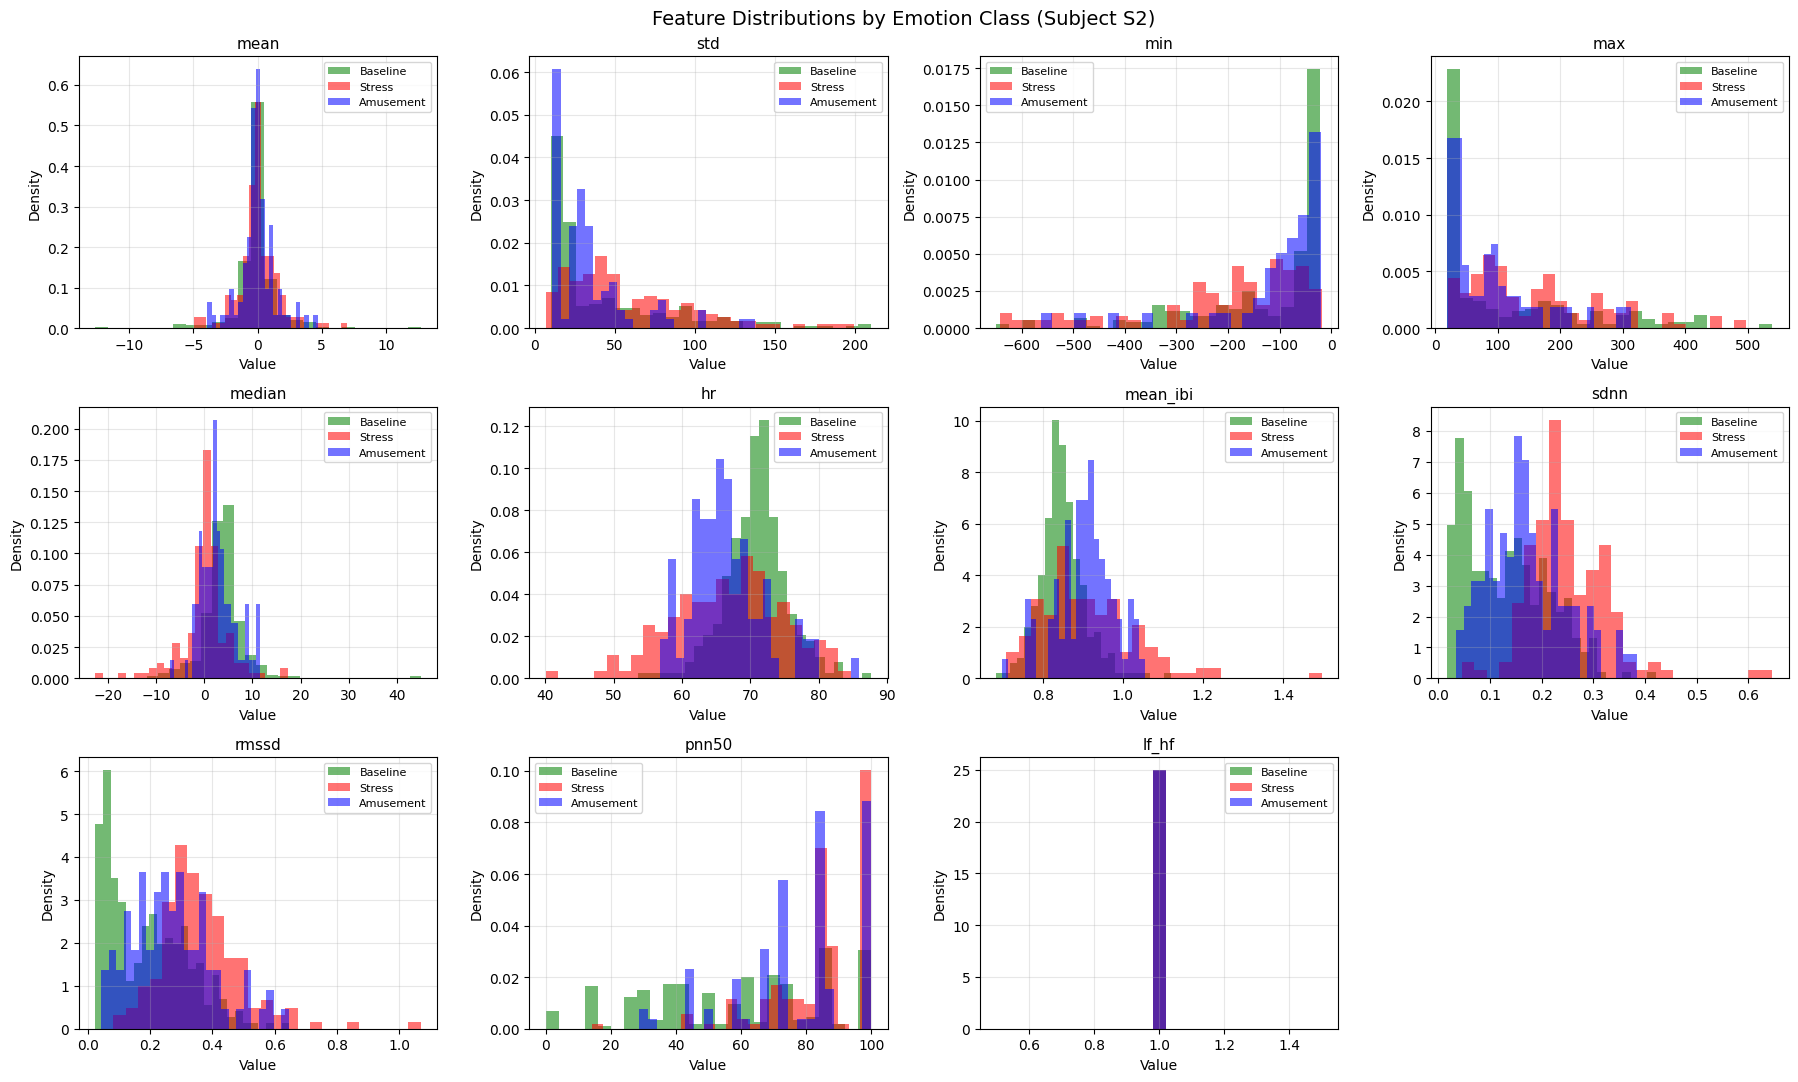

Saved: fig3_all_feature_distributions.png


In [10]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

colors_map = {1: 'green', 2: 'red', 3: 'blue'}

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    for lbl, name in EMOTION_LABELS.items():
        values = X_s2[y_s2 == lbl, i]
        ax.hist(values, bins=25, alpha=0.55, color=colors_map[lbl],
                label=name, density=True)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Emotion Class (Subject S2)', fontsize=14)
plt.tight_layout()
plt.savefig('fig3_all_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_all_feature_distributions.png")

## 9. Pipeline Summary

| Step | Action | Output |
|------|--------|--------|
| 1 | Load `S2.pkl`, extract wrist BVP + labels | PPG array (64 Hz), label array (700 Hz) |
| 2 | Butterworth bandpass 0.5–4 Hz, order 4, `filtfilt` | Filtered PPG (same length) |
| 3 | Align labels to PPG sample rate via index scaling | `labels_aligned` (same length as PPG) |
| 4 | Sliding window: 8 s / 512 samples, 50 % overlap, majority-vote label, discard non-emotion | `segments` (N, 512), `segment_labels` (N,) |
| 5 | Extract 11 HRV features per window | `X_s2` (N, 11), `y_s2` (N,) |

This pipeline is applied identically to all 15 subjects in **Section 2**.

In [11]:
print("=== Final Output (Subject S2) ===")
print(f"Feature matrix X_s2 : {X_s2.shape}  ({X_s2.shape[0]} windows × {X_s2.shape[1]} features)")
print(f"Label vector   y_s2 : {y_s2.shape}")
print(f"Classes         : {np.unique(y_s2)} → ",
      {int(k): v for k, v in EMOTION_LABELS.items()})
print(f"Feature names   : {FEATURE_NAMES}")

=== Final Output (Subject S2) ===
Feature matrix X_s2 : (531, 11)  (531 windows × 11 features)
Label vector   y_s2 : (531,)
Classes         : [1 2 3] →  {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
Feature names   : ['mean', 'std', 'min', 'max', 'median', 'hr', 'mean_ibi', 'sdnn', 'rmssd', 'pnn50', 'lf_hf']
